# No supervised Models


a diferencia de los modelos supervisados, en este caso los modelos no supervisados no tiene etiquetas de entrada en su valor y, esto quiere decir que no hay data con el valor esperado de la muestra, en este 
caso el modelo tiene que aprender a tratar de dar un valor sin los valores esperados

una forma de hacer esto es con K-means, en el cual tratamos de clasificar los datos por regiones
y aplicando una de las formas que es centroides tratamos de agrupar un valor cercano a ellos.

C:\Users\juanc\AppData\Local\Temp\ipykernel_2788\1490458716.py:44: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  centers[center][0] = sum_n_class[center][0] / total_n_class[center]
C:\Users\juanc\AppData\Local\Temp\ipykernel_2788\1490458716.py:46: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  centers[center][1] = sum_n_class[center][1] / total_n_class[center]


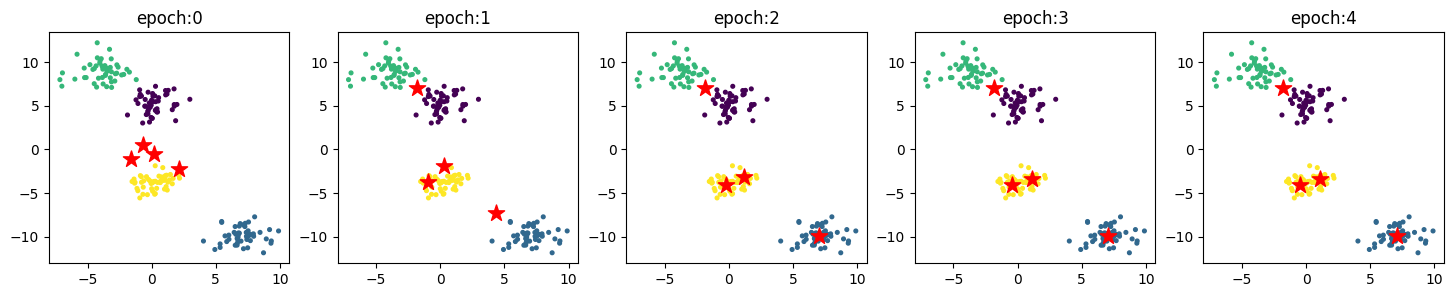

In [10]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial import distance

NUM_CLASSES = 4
NUM_FEATURE = 2

def euclidean(sample, center):
    return np.sqrt(distance.euclidean(sample,center))

def nearest_center(sample, centers):
    distance = []
    for i in range(len(centers)):
        distance.append(euclidean(sample,centers[i]))

    return np.argmin(distance)

X,y = make_blobs(n_samples=200,n_features=NUM_FEATURE,centers=NUM_CLASSES,
                 random_state=14)

fig,axs = plt.subplots(1,5, figsize=(18,3))

# vamos a generar los randoms centers
centers = np.random.randn(NUM_CLASSES,2)

for epoch,ax in zip(range(5),axs):
    ax.scatter(X[:,0],X[:,1], c=y,s=7)
    ax.scatter(centers[:,0],centers[:,1], marker='*', c='r', s=150)
    ax.set_title('epoch:'+format(epoch))

    sum_n_class = np.zeros((NUM_CLASSES,2))
    total_n_class = np.zeros((NUM_CLASSES,1))

    for i in range(len(X)):
        center = nearest_center(X[i],centers)

        total_n_class[center] += 1
        sum_n_class[center][0] += X[i][0]
        sum_n_class[center][1] += X[i][1]
    
    for center in range(NUM_CLASSES):
        if total_n_class[center] > 0:
            centers[center][0] = sum_n_class[center][0] / total_n_class[center]

            centers[center][1] = sum_n_class[center][1] / total_n_class[center]
        else:
            centers[center] = np.random.randn(2)
plt.show()